# Optimización de asignación de demanda sanitaria mediante Forecast, MILP y Ranking Multicriterio

## Objetivo

Este notebook analiza la reasignación óptima de demanda sanitaria prevista entre proveedores utilizando información histórica de costes, valoración y capacidad.

La metodología combina tres elementos:

1. **Forecast de demanda** por tratamiento y municipio para un horizonte de cuatro semanas.
2. **Modelo MILP de optimización** que minimiza el coste total matemáticamente.
3. **Ranking multicriterio** que permite ordenar proveedores con más flexibilidad.

## Flujo de trabajo

### 1. Preparación de datos

- Integración del histórico de actividad con los resultados del forecast.
- Construcción de las series objetivo definidas por:
  
  **Municipio + Tratamiento**

- Conversión de la capacidad anual declarada por los proveedores a capacidad disponible para el horizonte analizado.

### 2. Construcción del modelo de proveedores

Para cada combinación proveedor-municipio-tratamiento se calculan:

- coste medio histórico,
- valoración media,
- capacidad disponible,
- capacidad relativa respecto a la demanda prevista,
- variables normalizadas para el ranking multicriterio.

### 3. Optimización MILP

El modelo de programación lineal entera mixta (MILP) determina la distribución de servicios entre proveedores que minimiza el coste total cumpliendo simultáneamente:

- demanda prevista,
- restricciones de capacidad,
- valoración media mínima exigida.

La solución proporciona además las cuotas objetivo de asignación de cada proveedor.

### 4. Ranking Web

A partir de la información anterior se construye un índice multicriterio que permite priorizar proveedores.

El ranking utiliza:

- coste,
- valoración,
- capacidad relativa,
- cuota objetivo derivada del MILP.

Posteriormente se realiza una asignación operativa siguiendo dicho ranking y respetando las capacidades disponibles.

### 5. Sensibilidad

El notebook evalúa:

- distintos umbrales mínimos de valoración,
- distintas combinaciones de pesos del ranking.

El objetivo es estudiar el compromiso entre:

- ahorro económico,
- calidad asistencial,
- porcentaje de escenarios factibles.

### 6. Validación global

Todas las series objetivo son evaluadas bajo distintos escenarios de valoración para comparar:

- solución histórica de referencia,
- asignación basada en Ranking Web,
- solución óptima MILP.

Se calculan indicadores agregados de:

- coste,
- ahorro,
- valoración obtenida,
- factibilidad,
- cobertura de escenarios.


In [172]:
import numpy as np
import pandas as pd
from scipy.optimize import milp, LinearConstraint, Bounds, differential_evolution
from sklearn.preprocessing import MinMaxScaler
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RUTA_DATOS = "datos_tratamientos_detalle_con_rating_capacidad.xlsx"
RUTA_FORECAST = "forecast_por_serie_H1_H4.xlsx"

UMBRALES_VALORACION = [3.5, 3.7, 3.8, 4.0]
UMBRAL_INICIAL = 3.7

df = pd.read_excel(RUTA_DATOS)
forecast = pd.read_excel(RUTA_FORECAST)

print(f"Histórico cluster 4: {len(df):,} filas")
print(f"Series del forecast: {len(forecast):,}")
print(f"Valores de CAPACIDAD_ANUAL ausentes: {df['CAPACIDAD_ANUAL'].isna().sum():,}")

Histórico cluster 4: 7,628 filas
Series del forecast: 50
Valores de CAPACIDAD_ANUAL ausentes: 0


## 1. Valoración real y demanda prevista

In [173]:
n_rating_missing = df["rating_global"].isna().sum()
df["Valoracion"] = df["rating_global"].fillna(3.0)

cols_forecast = [
    "PREDICCION_H1", "PREDICCION_H2",
    "PREDICCION_H3", "PREDICCION_H4"
]
forecast[cols_forecast] = forecast[cols_forecast].apply(pd.to_numeric, errors="coerce").fillna(0)

forecast["DemandaForecast"] = forecast[cols_forecast].sum(axis=1)
forecast_completo = forecast.copy()
demanda_total_forecast = forecast_completo["DemandaForecast"].sum()
# Para la optimización, el volumen esperado se transforma en servicios
# operativos enteros mediante redondeo al servicio entero más cercano. Conservamos el forecast decimal
# original para su interpretación.
forecast["DemandaOperativa"] = np.rint(forecast["DemandaForecast"]).astype(int)
forecast = forecast[forecast["DemandaOperativa"] > 0].copy()

print(f"Ratings ausentes sustituidos por 3.0: {n_rating_missing:,}")
print(f"Series con demanda prevista > 0: {len(forecast):,}")
print(f"Demanda prevista total (50 series): {demanda_total_forecast:,.3f}")

Ratings ausentes sustituidos por 3.0: 1,831
Series con demanda prevista > 0: 45
Demanda prevista total (50 series): 290.197


## 2.Selección de las series objetivo

In [174]:
# Una serie objetivo queda definida por tratamiento + municipio.
series_objetivo = forecast[
    ["CODIGO_TRATAMIENTO", "CODIGO_MUNICIPIO",
     "DESCPROCED", "DESCMUNICIPIO",
     "PREDICCION_H1", "PREDICCION_H2",
     "PREDICCION_H3", "PREDICCION_H4",
     "DemandaForecast", "DemandaOperativa"]
].drop_duplicates()

# El histórico se restringe exclusivamente a esas series.
df_objetivo = df.merge(
    series_objetivo[["CODIGO_TRATAMIENTO", "CODIGO_MUNICIPIO"]],
    left_on=["CODIGO", "CODIGO_MUNICIPIO"],
    right_on=["CODIGO_TRATAMIENTO", "CODIGO_MUNICIPIO"],
    how="inner"
)

print(f"Series objetivo: {len(series_objetivo):,}")
print(f"Tratamientos objetivo: {series_objetivo['CODIGO_TRATAMIENTO'].nunique():,}")
print(f"Municipios objetivo: {series_objetivo['CODIGO_MUNICIPIO'].nunique():,}")
print(f"Registros históricos utilizados: {len(df_objetivo):,}")


Series objetivo: 45
Tratamientos objetivo: 38
Municipios objetivo: 4
Registros históricos utilizados: 7,551


## 3.Comprobación de la capacidad real

`CAPACIDAD_ANUAL` puede variar entre combinaciones del mismo proveedor. Se comprueba que dentro de cada combinación `proveedor + municipio + tratamiento` esté resgistrada la capacidad; en los datos utilizados esta condición se cumple. Las combinaciones sin capacidad conocida no forman parte de las series objetivo del forecast.


In [175]:
modelo = (
    df_objetivo.groupby(
        [
            "CODIGO_MUNICIPIO", "DESCMUNICIPIO",
            "CODPROVEEDOR", "NOMBREPROVEEDOR",
            "CODIGO", "DESCPROCED"
        ],
        as_index=False
    )
    .agg(
        CosteMedio=("SUMA", "mean"),
        NumCasos=("SUMA", "count"),
        Valoracion=("Valoracion", "mean"),
        CapacidadAnual=("CAPACIDAD_ANUAL", "first")
    )
)

# La capacidad anual es la capacidad total declarada para cada combinación
# proveedor + municipio + tratamiento.
modelo["Capacidad4Semanas"] = (
    modelo["CapacidadAnual"] * 4 / 52
)

print(
    f"Combinaciones ciudad-tratamiento-proveedor: {len(modelo):,}"
)
print(
    f"Combinaciones con capacidad anual conocida: "
    f"{modelo['CapacidadAnual'].notna().sum():,}"
)
print(
    f"Combinaciones con capacidad anual ausente: "
    f"{modelo['CapacidadAnual'].isna().sum():,}"
)

Combinaciones ciudad-tratamiento-proveedor: 400
Combinaciones con capacidad anual conocida: 400
Combinaciones con capacidad anual ausente: 0


## 4. Selector de ciudad, tratamiento y umbral de valoración

In [191]:
ciudades = (
    series_objetivo[["CODIGO_MUNICIPIO", "DESCMUNICIPIO"]]
    .drop_duplicates()
    .sort_values(["DESCMUNICIPIO", "CODIGO_MUNICIPIO"])
)

def tratamientos_de_ciudad(codigo_municipio):
    return (
        series_objetivo[series_objetivo["CODIGO_MUNICIPIO"] == codigo_municipio]
        [["CODIGO_TRATAMIENTO", "DESCPROCED"]]
        .drop_duplicates()
        .sort_values(["DESCPROCED", "CODIGO_TRATAMIENTO"])
    )

ciudad_inicial = ciudades.iloc[0]["CODIGO_MUNICIPIO"]
tratamientos_iniciales = tratamientos_de_ciudad(ciudad_inicial)

selector_ciudad = widgets.Dropdown(
    options=[(f"{n} - {c}", c) for c, n in ciudades.itertuples(index=False, name=None)],
    value=ciudad_inicial,
    description="Ciudad:",
    layout=widgets.Layout(width="800px")
)

selector_tratamiento = widgets.Dropdown(
    options=[(f"{n} - {c}", c) for c, n in tratamientos_iniciales.itertuples(index=False, name=None)],
    value=tratamientos_iniciales.iloc[0]["CODIGO_TRATAMIENTO"],
    description="Tratamiento:",
    layout=widgets.Layout(width="800px")
)

selector_umbral = widgets.Dropdown(
    options=[(f"{u:.1f}", u) for u in UMBRALES_VALORACION],
    value=UMBRAL_INICIAL,
    description="Valoración mínima:",
    layout=widgets.Layout(width="300px")
)

def actualizar_tratamientos(change):
    tratamientos = tratamientos_de_ciudad(change["new"])
    selector_tratamiento.options = [
        (f"{n} - {c}", c)
        for c, n in tratamientos.itertuples(index=False, name=None)
    ]
    if len(tratamientos):
        selector_tratamiento.value = tratamientos.iloc[0]["CODIGO_TRATAMIENTO"]

selector_ciudad.observe(actualizar_tratamientos, names="value")

display(selector_ciudad)
display(selector_tratamiento)
display(selector_umbral)

Dropdown(description='Ciudad:', layout=Layout(width='800px'), options=(('CHACAO - 015-007-007', '015-007-007')…

Dropdown(description='Tratamiento:', layout=Layout(width='800px'), options=(('MEDICINA INTERNA CONSULTA 1A VEZ…

Dropdown(description='Valoración mínima:', index=1, layout=Layout(width='300px'), options=(('3.5', 3.5), ('3.7…

### ¿Qué significa el selector de umbral?

El programa calcula la sensibilidad para **todos** los umbrales, pero el análisis principal utiliza únicamente el umbral que se seleccione aquí.

Por ejemplo, si se selecciona **3.7**, la pregunta es:

> ¿Cuál es el coste mínimo que podemos alcanzar manteniendo una valoración media de al menos 3.7?

No se selecciona automáticamente 3.5 por producir más ahorro.

## 5.Funciones del Modelo

In [177]:
def normalizar_minmax(grupo, invertir=False):
    """
    Normalización 0-1 dentro de cada serie ciudad + tratamiento.
    Si invertir=True, los valores menores reciben mayor puntuación.
    """
    minimo = grupo.min()
    maximo = grupo.max()

    if np.isclose(minimo, maximo):
        resultado = pd.Series(1.0, index=grupo.index)
    else:
        resultado = (grupo - minimo) / (maximo - minimo)

    if invertir:
        resultado = 1 - resultado

    return resultado


# -------------------------------------------------------------------------
# Variables de puntuación
# -------------------------------------------------------------------------
# La demanda se incorpora a la tabla de proveedores para poder medir la
# capacidad en relación con el volumen esperado, no de forma absoluta.

modelo = modelo.merge(
    series_objetivo[
        [
            "CODIGO_TRATAMIENTO",
            "CODIGO_MUNICIPIO",
            "DemandaForecast",
            "DemandaOperativa"
        ]
    ].drop_duplicates(),
    left_on=["CODIGO", "CODIGO_MUNICIPIO"],
    right_on=["CODIGO_TRATAMIENTO", "CODIGO_MUNICIPIO"],
    how="inner"
)

modelo["Capacidad4Semanas"] = (
    modelo["CapacidadAnual"] * 4 / 52
)

# CosteNormalizado: 0 = más barato, 1 = más caro.
# ScoreCoste: 1 = más barato, 0 = más caro.
modelo["CosteNormalizado"] = (
    modelo.groupby(["CODIGO_MUNICIPIO", "CODIGO"])["CosteMedio"]
    .transform(normalizar_minmax)
)

modelo["ScoreCoste"] = (
    1 - modelo["CosteNormalizado"]
)

modelo["ValoracionNormalizada"] = (
    modelo.groupby(["CODIGO_MUNICIPIO", "CODIGO"])["Valoracion"]
    .transform(normalizar_minmax)
)

modelo["CapacidadRelativa"] = (
    modelo["Capacidad4Semanas"]
    / modelo["DemandaForecast"].replace(0, np.nan)
)

modelo["CapacidadRelativa"] = (
    modelo["CapacidadRelativa"].replace([np.inf, -np.inf], np.nan).fillna(0)
)

modelo["ScoreCapacidad"] = (
    modelo.groupby(["CODIGO_MUNICIPIO", "CODIGO"])["CapacidadRelativa"]
    .transform(normalizar_minmax)
)

print(f"Combinaciones ciudad-tratamiento-proveedor: {len(modelo):,}")
print(
    f"Combinaciones con capacidad anual conocida: "
    f"{modelo['CapacidadAnual'].notna().sum():,}"
)
print(
    f"Combinaciones con capacidad anual ausente: "
    f"{modelo['CapacidadAnual'].isna().sum():,}"
)


def calcular_indice(
    data,
    peso_coste=0.30,
    peso_valoracion=0.30,
    peso_capacidad=0.20,
    peso_cuota=0.20
):
    """
    Ranking multicriterio. Todos los componentes son puntuaciones
    donde un valor mayor representa una situación más favorable.
    """
    return (
        peso_coste * data["ScoreCoste"]
        + peso_valoracion * data["ValoracionNormalizada"]
        + peso_capacidad * data["ScoreCapacidad"]
        + peso_cuota * data["ScoreCuotaMILP"]
    )


def obtener_datos(ciudad, tratamiento):
    datos = modelo[
        (modelo["CODIGO_MUNICIPIO"] == ciudad)
        & (modelo["CODIGO"] == tratamiento)
    ].copy()

    datos = datos.dropna(
        subset=["CapacidadAnual", "Capacidad4Semanas"]
    ).copy()

    if datos.empty:
        raise ValueError(
            "No existe una serie objetivo con capacidad conocida "
            "para la ciudad y tratamiento seleccionados."
        )

    return datos


def obtener_forecast(ciudad, tratamiento):
    f = forecast[
        (forecast["CODIGO_MUNICIPIO"] == ciudad)
        & (forecast["CODIGO_TRATAMIENTO"] == tratamiento)
    ].copy()

    if f.empty:
        raise ValueError("No existe forecast para esa serie.")

    return f.iloc[0]


def crear_capacidad_maxima(datos):
    """Adapta la capacidad anual real al horizonte de cuatro semanas."""
    datos = datos.copy()
    datos["CapacidadMaxima"] = datos["Capacidad4Semanas"]
    return datos


def demanda_forecast(ciudad, tratamiento):
    f = forecast[
        (forecast["CODIGO_MUNICIPIO"] == ciudad)
        & (forecast["CODIGO_TRATAMIENTO"] == tratamiento)
    ].copy()

    if f.empty:
        raise ValueError("No existe forecast para esa serie.")

    return int(f.iloc[0]["DemandaOperativa"])


def calcular_presion_mercado(datos, demanda):
    """
    Indicador de tensión entre demanda prevista y capacidad.

    Presión < 1:
       existe capacidad suficiente.

    Presión ≈ 1:
        mercado tensionado.

    Presión > 1:
        la demanda supera la capacidad disponible.
    """

    capacidad_total = datos["Capacidad4Semanas"].sum()

    if capacidad_total <= 0:
        return np.inf

    return demanda / capacidad_total


def coste_referencia_forecast(datos, demanda):
    coste_medio_historico = np.average(
        datos["CosteMedio"],
        weights=datos["NumCasos"]
    )
    valoracion_historica = np.average(
        datos["Valoracion"],
        weights=datos["NumCasos"]
    )

    return {
        "CosteTotal": coste_medio_historico * demanda,
        "ValoracionMedia": valoracion_historica
    }


def asignar_por_indice(
    datos,
    demanda,
    peso_coste=0.30,
    peso_valoracion=0.30,
    peso_capacidad=0.20,
    peso_cuota=0.20,
    umbral_valoracion=None,
    cuotas_objetivo=None
):
    """
    Simula la asignación realizada por el Ranking Web.

    Los proveedores se ordenan según el índice multicriterio.
    Posteriormente la demanda se asigna siguiendo dicho orden y
    respetando las capacidades.

    """
    datos = crear_capacidad_maxima(datos).copy()

    if umbral_valoracion is not None:
        datos = datos[
            datos["Valoracion"] >= umbral_valoracion
        ].copy()

    if datos.empty:
        return {
            "Factible": False,
            "CosteTotal": np.nan,
            "ValoracionMedia": np.nan,
            "SinAsignar": demanda,
            "Asignaciones": pd.DataFrame()
        }

    # Si el MILP no es factible para una serie, no existen cuotas objetivo.
    # En ese caso todos los proveedores reciben CuotaObjetivo = 0 y
    # continúan siendo evaluables por el Ranking Web.
    if (
        cuotas_objetivo is None
        or cuotas_objetivo.empty
        or not {"CODPROVEEDOR", "CuotaObjetivo"}.issubset(cuotas_objetivo.columns)
    ):
        datos["CuotaObjetivo"] = 0.0
    else:
        datos = datos.merge(
            cuotas_objetivo[
                ["CODPROVEEDOR", "CuotaObjetivo"]
            ],
            on="CODPROVEEDOR",
            how="left"
        )
        datos["CuotaObjetivo"] = datos["CuotaObjetivo"].fillna(0.0)

    max_cuota = datos["CuotaObjetivo"].max()
    if max_cuota > 0:
        datos["ScoreCuotaMILP"] = (
            datos["CuotaObjetivo"] / max_cuota
        )
    else:
        datos["ScoreCuotaMILP"] = 0.0

    datos["Indice"] = calcular_indice(
        datos,
        peso_coste,
        peso_valoracion,
        peso_capacidad,
        peso_cuota
    )

    datos = datos.sort_values(
        ["Indice", "CosteMedio"],
        ascending=[False, True]
    )

    restantes = int(demanda)
    asignaciones = []

    for _, fila in datos.iterrows():
        if restantes <= 0:
            break

        asignados = min(
            restantes,
            int(np.floor(fila["CapacidadMaxima"] + 1e-9))
        )

        if asignados > 0:
            asignaciones.append({
                "CODPROVEEDOR": fila["CODPROVEEDOR"],
                "NOMBREPROVEEDOR": fila["NOMBREPROVEEDOR"],
                "Servicios": asignados,
                "CosteMedio": fila["CosteMedio"],
                "Valoracion": fila["Valoracion"],
                "CapacidadAnual": fila["CapacidadAnual"],
                "Capacidad4Semanas": fila["Capacidad4Semanas"],
                "Indice": fila["Indice"]
            })
            restantes -= asignados

    asignaciones = pd.DataFrame(asignaciones)

    if asignaciones.empty or restantes > 0:
        return {
            "Factible": False,
            "CosteTotal": np.nan,
            "ValoracionMedia": np.nan,
            "SinAsignar": restantes,
            "Asignaciones": asignaciones
        }

    coste_total = (
        asignaciones["Servicios"]
        * asignaciones["CosteMedio"]
    ).sum()

    valoracion_media = np.average(
        asignaciones["Valoracion"],
        weights=asignaciones["Servicios"]
    )

    return {
        "Factible": True,
        "CosteTotal": coste_total,
        "ValoracionMedia": valoracion_media,
        "SinAsignar": 0,
        "Asignaciones": asignaciones
    }


def optimizar_coste(
    datos,
    demanda,
    umbral_valoracion
):
    """
    MILP de minimización de coste.

    Para cada proveedor se decide cuántos servicios recibe (x_i).
    Se minimiza el coste total respetando:
        - satisfacción exacta de la demanda operativa;
        - capacidad disponible;
        - valoración media >= umbral seleccionado.

    Este es el objetivo económico principal del MILP. La valoración
    actúa como restricción de calidad y no como parte de la función objetivo.
    """
    datos = crear_capacidad_maxima(datos).reset_index(drop=True)
    n = len(datos)
    demanda = int(demanda)

    if n == 0 or demanda <= 0:
        return {
            "Factible": False,
            "Mensaje": "Demanda no válida o no existen proveedores.",
            "CosteTotal": np.nan,
            "ValoracionMedia": np.nan,
            "SinAsignar": demanda,
            "Asignaciones": pd.DataFrame()
        }

    costes = datos["CosteMedio"].to_numpy(dtype=float)
    valoraciones = datos["Valoracion"].to_numpy(dtype=float)
    capacidades = np.floor(
        datos["CapacidadMaxima"].to_numpy(dtype=float) + 1e-9
    )

    # Función objetivo: minimizar el coste total.
    c = costes

    # Restricciones lineales:
    # 1) atender exactamente toda la demanda;
    # 2) mantener la valoración media por encima del umbral.
    A = np.vstack([
        np.ones(n),
        valoraciones
    ])

    lb = np.array([
        demanda,
        demanda * umbral_valoracion
    ], dtype=float)

    ub = np.array([
        demanda,
        np.inf
    ], dtype=float)

    resultado = milp(
        c=c,
        integrality=np.ones(n),
        bounds=Bounds(np.zeros(n), capacidades),
        constraints=LinearConstraint(A, lb, ub),
        options={"time_limit": 30}
    )

    if not resultado.success:
        return {
            "Factible": False,
            "Mensaje": resultado.message,
            "CosteTotal": np.nan,
            "ValoracionMedia": np.nan,
            "SinAsignar": demanda,
            "Asignaciones": pd.DataFrame()
        }

    x = np.rint(resultado.x).astype(int)

    coste_total = np.sum(x * costes)
    valoracion_media = np.sum(x * valoraciones) / demanda

    asignaciones = datos.loc[
        x > 0,
        [
            "CODPROVEEDOR",
            "NOMBREPROVEEDOR",
            "CosteMedio",
            "Valoracion",
            "CapacidadAnual",
            "Capacidad4Semanas"
        ]
    ].copy()

    asignaciones["Servicios"] = x[x > 0]
    asignaciones["CosteTotal"] = (
        asignaciones["Servicios"]
        * asignaciones["CosteMedio"]
    )

    asignaciones = asignaciones.sort_values(
        "Servicios",
        ascending=False
    )

    return {
        "Factible": True,
        "Mensaje": resultado.message,
        "CosteTotal": coste_total,
        "ValoracionMedia": valoracion_media,
        "SinAsignar": 0,
        "Asignaciones": asignaciones
    }

def obtener_cuotas_objetivo(
    datos,
    demanda,
    umbral,
):
    """
Calcula la cuota objetivo de cada proveedor a partir
de la solución de mínimo coste obtenida por el MILP.

La cuota representa el porcentaje de la demanda que
el MILP asigna a cada proveedor.
"""
    opt = optimizar_coste(
        datos,
        demanda,
        umbral,
        )

    if not opt["Factible"]:
        return pd.DataFrame()

    cuotas = opt["Asignaciones"].copy()

    cuotas["CuotaObjetivo"] = (
        cuotas["Servicios"]
        / cuotas["Servicios"].sum()
    )

    return cuotas[
        [
            "CODPROVEEDOR",
            "NOMBREPROVEEDOR",
            "Servicios",
            "CuotaObjetivo"
        ]
    ]



def obtener_ranking_web(
    ciudad,
    tratamiento,
    umbral,
    cuotas_objetivo=None,
    peso_coste=0.30,
    peso_valoracion=0.30,
    peso_capacidad=0.20,
    peso_cuota=0.20
):
    """
    Ranking web que devuelve TODOS los proveedores viables:
        Valoracion >= umbral
        Capacidad4Semanas > 0

    Las cuotas MILP solo aportan una puntuación; no excluyen proveedores.
    """

    datos = obtener_datos(
        ciudad,
        tratamiento
    ).copy()

    datos = crear_capacidad_maxima(datos)

    datos = datos[
        (datos["Valoracion"] >= umbral)
        & (datos["Capacidad4Semanas"] > 0)
    ].copy()

    if datos.empty:
        return pd.DataFrame()

    # LEFT JOIN: un proveedor con CuotaObjetivo = 0 sigue visible.
    if cuotas_objetivo is not None and not cuotas_objetivo.empty:
        datos = datos.merge(
            cuotas_objetivo[
                ["CODPROVEEDOR", "CuotaObjetivo"]
            ],
            on="CODPROVEEDOR",
            how="left"
        )
    else:
        datos["CuotaObjetivo"] = 0.0

    datos["CuotaObjetivo"] = (
        datos["CuotaObjetivo"].fillna(0.0)
    )

    max_cuota = datos["CuotaObjetivo"].max()

    if max_cuota > 0:
        datos["ScoreCuotaMILP"] = (
            datos["CuotaObjetivo"] / max_cuota
        )
    else:
        datos["ScoreCuotaMILP"] = 0.0

    datos["RankingWeb"] = calcular_indice(
        datos,
        peso_coste,
        peso_valoracion,
        peso_capacidad,
        peso_cuota
    )

    datos = datos.sort_values(
        ["RankingWeb", "CosteMedio"],
        ascending=[False, True]
    )

    return datos[
        [
            "CODPROVEEDOR",
            "NOMBREPROVEEDOR",
            "CosteMedio",
            "Valoracion",
            "Capacidad4Semanas",
            "CapacidadRelativa",
            "CuotaObjetivo",
            "ScoreCoste",
            "ScoreCapacidad",
            "ScoreCuotaMILP",
            "RankingWeb"
        ]
    ]


def analizar_umbrales(
    datos,
    demanda,
    umbrales=UMBRALES_VALORACION,
):
    referencia = coste_referencia_forecast(
        datos,
        demanda
    )

    filas = []

    for umbral in umbrales:
        opt = optimizar_coste(
            datos,
            demanda,
            umbral,
                )

        if opt["Factible"]:
            ahorro_ref = (
                referencia["CosteTotal"]
                - opt["CosteTotal"]
            )

            ahorro_ref_pct = (
                100 * ahorro_ref
                / referencia["CosteTotal"]
            )

            motivo = "Factible"
        else:
            ahorro_ref = np.nan
            ahorro_ref_pct = np.nan
            motivo = "No factible"

        filas.append({
            "UmbralValoracion": umbral,
            "Factible": opt["Factible"],
            "Motivo": motivo,
            "CosteReferenciaForecast": referencia["CosteTotal"],
            "CosteOptimizado": opt["CosteTotal"],
            "AhorroVsReferencia": ahorro_ref,
            "AhorroPctVsReferencia": ahorro_ref_pct,
            "ValoracionOptimizada": opt["ValoracionMedia"],
            "SinAsignar": opt["SinAsignar"]
        })

    return pd.DataFrame(filas)


Combinaciones ciudad-tratamiento-proveedor: 400
Combinaciones con capacidad anual conocida: 400
Combinaciones con capacidad anual ausente: 0


## 6. Resultado de la serie escogida

In [226]:
CIUDAD_SELECCIONADA = selector_ciudad.value
TRATAMIENTO_SELECCIONADO = selector_tratamiento.value
UMBRAL_SELECCIONADO = float(selector_umbral.value)

datos_seleccion = obtener_datos(
    CIUDAD_SELECCIONADA,
    TRATAMIENTO_SELECCIONADO
)

forecast_seleccion = obtener_forecast(
    CIUDAD_SELECCIONADA,
    TRATAMIENTO_SELECCIONADO
)

DEMANDA = demanda_forecast(
    CIUDAD_SELECCIONADA,
    TRATAMIENTO_SELECCIONADO
)

referencia = coste_referencia_forecast(
    datos_seleccion,
    DEMANDA
)

# MILP: minimización del coste con restricción de valoración mínima.
optimo_seleccionado = optimizar_coste(
    datos_seleccion,
    DEMANDA,
    UMBRAL_SELECCIONADO,
)

if optimo_seleccionado["Factible"]:
    cuotas_objetivo_seleccion = obtener_cuotas_objetivo(
        datos_seleccion,
        DEMANDA,
        UMBRAL_SELECCIONADO,
        )

    coste_milp = optimo_seleccionado["CosteTotal"]
    valoracion_milp = optimo_seleccionado["ValoracionMedia"]
else:
    cuotas_objetivo_seleccion = pd.DataFrame()
    coste_milp = np.nan
    valoracion_milp = np.nan

print(f"Ciudad: {datos_seleccion['DESCMUNICIPIO'].iloc[0]}")
print(f"Tratamiento: {datos_seleccion['DESCPROCED'].iloc[0]}")
print(f"Demanda prevista (forecast): {forecast_seleccion['DemandaForecast']:,.3f}")
print(f"Demanda operativa utilizada: {DEMANDA:,}")
print(f"Forecast H1-H4: {np.round(forecast_seleccion[cols_forecast], 3)}")
print(f"Umbral seleccionado: {UMBRAL_SELECCIONADO:.1f}")
print(f"Presión de mercado: {calcular_presion_mercado(datos_seleccion, DEMANDA):,.3f}")
print(f"Coste referencia: {referencia['CosteTotal']:,.2f} €")
print(f"Coste MILP: {coste_milp:,.2f} €")
print(f"Valoración MILP: {valoracion_milp:.3f}")



Ciudad: LIBERTADOR
Tratamiento: MAPA   MONITOREO DE TENSION ARTERIAL POR 24 HORAS
Demanda prevista (forecast): 3.399
Demanda operativa utilizada: 3
Forecast H1-H4: PREDICCION_H1   0.662
PREDICCION_H2   0.518
PREDICCION_H3   0.719
PREDICCION_H4   1.500
Name: 41, dtype: object
Umbral seleccionado: 3.7
Presión de mercado: 0.156
Coste referencia: 211.64 €
Coste MILP: 162.64 €
Valoración MILP: 3.700


## 7. Sensibilidad del umbral de valoración

Se mantienen los cuatro umbrales como escenarios alternativos. Esta sensibilidad responde a una pregunta distinta del análisis de pesos: qué compromiso existe entre calidad mínima exigida y coste cuando el MILP debe cumplir el umbral seleccionado.

El programa **no elige automáticamente** el umbral de valoración.

In [227]:
sensibilidad = analizar_umbrales(
    datos_seleccion,
    DEMANDA,
    UMBRALES_VALORACION,
)

display(
    sensibilidad.round(3)
)


,UmbralValoracion,Factible,Motivo,CosteReferenciaForecast,CosteOptimizado,AhorroVsReferencia,AhorroPctVsReferencia,ValoracionOptimizada,SinAsignar
0,3.500,True,Factible,211.643,162.636,49.006,23.155,3.700,0
1,3.700,True,Factible,211.643,162.636,49.006,23.155,3.700,0
2,3.800,True,Factible,211.643,174.499,37.144,17.550,4.000,0
3,4.000,True,Factible,211.643,174.499,37.144,17.550,4.000,0


## 8. Asignación de proveedores para el umbral seleccionado

In [228]:
optimo_seleccionado = optimizar_coste(
    datos_seleccion,
    DEMANDA,
    UMBRAL_SELECCIONADO,
)

if optimo_seleccionado["Factible"]:

    tabla_milp = optimo_seleccionado["Asignaciones"].copy()

    tabla_milp["CuotaObjetivo"] = (
        tabla_milp["Servicios"]
        / tabla_milp["Servicios"].sum()
    )

    display(
        tabla_milp[
            [
                "CODPROVEEDOR",
                "NOMBREPROVEEDOR",
                "Servicios",
                "CuotaObjetivo",
                "CosteMedio",
                "CosteTotal",
                "Valoracion",
                "CapacidadAnual",
                "Capacidad4Semanas"
            ]
        ].round(3)
    )

else:
    print(optimo_seleccionado["Mensaje"])

,CODPROVEEDOR,NOMBREPROVEEDOR,Servicios,CuotaObjetivo,CosteMedio,CosteTotal,Valoracion,CapacidadAnual,Capacidad4Semanas
1,1134,CENTRO CLINICO FENIX SALUD C.A,1,0.333,55.683,55.683,4.000,20,1.538
2,1994,INVERSIONES LOPCYMASTER 2008 C.A.,1,0.333,58.379,58.379,4.100,20,1.538
7,34737,CLINICA INTEGRAL HERMA SALUDC.A,1,0.333,48.575,48.575,3.000,20,1.538


## 9. Análisis de sensibilidad de los pesos del Ranking Web

Los pesos se estudian sistemáticamente dentro de los intervalos definidos:

| Criterio | Rango |
|---|---:|
| Coste | 20%–50% |
| Valoración | 20%–50% |
| Capacidad | 10%–30% |
| Cuota objetivo MILP | 10%–30% |

Se utilizan incrementos de 5 puntos porcentuales y solo se conservan las combinaciones cuya suma sea exactamente 100%.

Cada combinación se prueba sobre **todas las series objetivo con demanda operativa positiva**, utilizando el umbral seleccionado.

Para comparar las configuraciones se calculan:

- ahorro total frente al coste de referencia;
- ahorro porcentual frente a la referencia;
- valoración media obtenida;
- número y porcentaje de escenarios factibles.

La selección recomendada se basa en la media de tres indicadores normalizados: ahorro, valoración y porcentaje de escenarios factibles. De esta forma no se decide el peso únicamente por el ahorro económico.

> **Tratamiento de escenarios no factibles en el MILP:** si el MILP no puede generar cuotas objetivo para una serie, el análisis de sensibilidad no elimina automáticamente la serie. La cuota se considera 0 para todos los proveedores y la factibilidad del ranking se determina por la capacidad disponible y el umbral de valoración.

In [181]:
PASO_PESOS = 0.05

def generar_combinaciones_pesos(paso=PASO_PESOS):
    """
    Genera todas las combinaciones factibles dentro de los rangos
    establecidos y cuya suma sea 1.
    """
    valores_coste = np.arange(0.20, 0.50 + paso / 2, paso)
    valores_valoracion = np.arange(0.20, 0.50 + paso / 2, paso)
    valores_capacidad = np.arange(0.10, 0.30 + paso / 2, paso)
    valores_cuota = np.arange(0.10, 0.30 + paso / 2, paso)

    combinaciones = []

    for pc in valores_coste:
        for pv in valores_valoracion:
            for pcap in valores_capacidad:
                for pcuota in valores_cuota:
                    if np.isclose(pc + pv + pcap + pcuota, 1.0):
                        combinaciones.append({
                            "PesoCoste": round(float(pc), 2),
                            "PesoValoracion": round(float(pv), 2),
                            "PesoCapacidad": round(float(pcap), 2),
                            "PesoCuotaMILP": round(float(pcuota), 2)
                        })

    return pd.DataFrame(combinaciones).drop_duplicates().reset_index(drop=True)


def evaluar_sensibilidad_pesos(
    series,
    umbral,
    paso=PASO_PESOS
):
    """
    Evalúa cada combinación de pesos sobre todas las series objetivo.

    La cuota objetivo se calcula una sola vez por serie, ya que depende
    del MILP y no de los pesos del Ranking Web.
    """
    candidatos = generar_combinaciones_pesos(paso)
    filas = []

    # Precalcular los elementos que no dependen de los pesos.
    escenarios = []

    for _, serie in series.iterrows():
        ciudad = serie["CODIGO_MUNICIPIO"]
        tratamiento = serie["CODIGO_TRATAMIENTO"]
        demanda = int(serie["DemandaOperativa"])

        if demanda <= 0:
            continue

        datos_t = obtener_datos(
            ciudad,
            tratamiento
        )

        referencia_t = coste_referencia_forecast(
            datos_t,
            demanda
        )

        cuotas_t = obtener_cuotas_objetivo(
            datos_t,
            demanda,
            umbral,
                )

        escenarios.append({
            "Ciudad": ciudad,
            "Tratamiento": tratamiento,
            "Demanda": demanda,
            "Datos": datos_t,
            "Referencia": referencia_t,
            "Cuotas": cuotas_t
        })

    for _, pesos in candidatos.iterrows():

        coste_asignado = 0.0
        coste_referencia = 0.0
        valoracion_total = 0.0
        demanda_factible = 0
        escenarios_factibles = 0

        for escenario in escenarios:
            resultado = asignar_por_indice(
                escenario["Datos"],
                escenario["Demanda"],
                peso_coste=pesos["PesoCoste"],
                peso_valoracion=pesos["PesoValoracion"],
                peso_capacidad=pesos["PesoCapacidad"],
                peso_cuota=pesos["PesoCuotaMILP"],
                umbral_valoracion=umbral,
                cuotas_objetivo=escenario["Cuotas"]
            )

            if resultado["Factible"]:
                escenarios_factibles += 1
                demanda_factible += escenario["Demanda"]
                coste_asignado += resultado["CosteTotal"]
                coste_referencia += escenario["Referencia"]["CosteTotal"]
                valoracion_total += (
                    resultado["ValoracionMedia"]
                    * escenario["Demanda"]
                )

        if escenarios_factibles > 0:
            ahorro_total = coste_referencia - coste_asignado
            ahorro_pct = (
                100 * ahorro_total / coste_referencia
                if coste_referencia > 0
                else np.nan
            )
            valoracion_media = (
                valoracion_total / demanda_factible
            )
        else:
            ahorro_total = np.nan
            ahorro_pct = np.nan
            valoracion_media = np.nan


        total_escenarios = len(escenarios)

        filas.append({
            **pesos.to_dict(),
            "EscenariosFactibles": escenarios_factibles,
            "EscenariosTotales": total_escenarios,
            "PctEscenariosFactibles": (
                100 * escenarios_factibles / total_escenarios
                if total_escenarios > 0
                else np.nan
            ),
            "DemandaFactible": demanda_factible,
            "AhorroTotal": ahorro_total,
            "AhorroPct": ahorro_pct,
            "ValoracionMedia": valoracion_media
        })

    resultado = pd.DataFrame(filas)

    # Puntuación de decisión: igual importancia a ahorro, calidad y factibilidad.
    # Cada indicador se normaliza entre las configuraciones evaluadas.
    def score_columna(columna):
        minimo = resultado[columna].min()
        maximo = resultado[columna].max()

        if pd.isna(minimo) or np.isclose(minimo, maximo):
            return pd.Series(1.0, index=resultado.index)

        return (
            resultado[columna] - minimo
        ) / (maximo - minimo)

    resultado["ScoreAhorro"] = score_columna("AhorroPct")
    resultado["ScoreValoracion"] = score_columna("ValoracionMedia")
    resultado["ScoreFactibilidad"] = score_columna(
        "PctEscenariosFactibles"
    )

    resultado["ScoreSensibilidad"] = (
        resultado["ScoreAhorro"]
        + resultado["ScoreValoracion"]
        + resultado["ScoreFactibilidad"]
    ) / 3

    resultado = resultado.sort_values(
        [
            "ScoreSensibilidad",
            "AhorroPct",
            "PctEscenariosFactibles",
            "ValoracionMedia"
        ],
        ascending=False
    ).reset_index(drop=True)

    resultado["Posicion"] = np.arange(1, len(resultado) + 1)

    return resultado


sensibilidad_pesos = evaluar_sensibilidad_pesos(
    series_objetivo,
    UMBRAL_SELECCIONADO,
)

print(
    f"Combinaciones de pesos evaluadas: "
    f"{len(sensibilidad_pesos):,}"
)

display(
    sensibilidad_pesos[
        [
            "Posicion",
            "PesoCoste",
            "PesoValoracion",
            "PesoCapacidad",
            "PesoCuotaMILP",
            "AhorroTotal",
            "AhorroPct",
            "ValoracionMedia",
            "EscenariosFactibles",
            "PctEscenariosFactibles",
            "ScoreSensibilidad"
        ]
    ].head(15).round(3)
)


Combinaciones de pesos evaluadas: 117


,Posicion,PesoCoste,PesoValoracion,PesoCapacidad,PesoCuotaMILP,AhorroTotal,AhorroPct,ValoracionMedia,EscenariosFactibles,PctEscenariosFactibles,ScoreSensibilidad
0,1,0.350,0.450,0.100,0.100,"8,572.982",14.913,4.082,38,84.444,0.814
1,2,0.300,0.500,0.100,0.100,"-2,845.702",-4.950,4.096,38,84.444,0.812
2,3,0.400,0.400,0.100,0.100,"10,243.790",17.820,4.078,38,84.444,0.790
3,4,0.300,0.450,0.150,0.100,"8,567.724",14.904,4.079,38,84.444,0.788
4,5,0.350,0.400,0.150,0.100,"8,567.724",14.904,4.079,38,84.444,0.788
5,6,0.450,0.350,0.100,0.100,"10,244.117",17.821,4.076,38,84.444,0.777
6,7,0.500,0.300,0.100,0.100,"10,244.117",17.821,4.076,38,84.444,0.777
7,8,0.400,0.350,0.150,0.100,"10,239.598",17.813,4.076,38,84.444,0.776
8,9,0.450,0.300,0.150,0.100,"10,239.598",17.813,4.076,38,84.444,0.776
9,10,0.400,0.350,0.100,0.150,"10,239.926",17.813,4.075,38,84.444,0.764


### Comparación de configuraciones representativas

Además de la configuración recomendada, se muestran algunas alternativas representativas para comprobar cómo cambia el comportamiento del sistema al desplazar peso hacia el coste, la valoración, la capacidad o la cuota MILP.

In [182]:
# Configuraciones representativas:
# - recomendada por el análisis;
# - equilibrio 30/30/20/20;
# - mayor peso al coste;
# - mayor peso a valoración;
# - mayor peso a capacidad;
# - mayor peso a cuota MILP.

recomendada = sensibilidad_pesos.iloc[0]

configuraciones = pd.DataFrame([
    {
        "Configuracion": "Recomendada",
        "PesoCoste": recomendada["PesoCoste"],
        "PesoValoracion": recomendada["PesoValoracion"],
        "PesoCapacidad": recomendada["PesoCapacidad"],
        "PesoCuotaMILP": recomendada["PesoCuotaMILP"]
    },
    {
        "Configuracion": "Equilibrada",
        "PesoCoste": 0.30,
        "PesoValoracion": 0.30,
        "PesoCapacidad": 0.20,
        "PesoCuotaMILP": 0.20
    },
    {
        "Configuracion": "Coste alto",
        "PesoCoste": 0.50,
        "PesoValoracion": 0.20,
        "PesoCapacidad": 0.15,
        "PesoCuotaMILP": 0.15
    },
    {
        "Configuracion": "Valoración alta",
        "PesoCoste": 0.20,
        "PesoValoracion": 0.50,
        "PesoCapacidad": 0.15,
        "PesoCuotaMILP": 0.15
    },
    {
        "Configuracion": "Capacidad alta",
        "PesoCoste": 0.30,
        "PesoValoracion": 0.20,
        "PesoCapacidad": 0.30,
        "PesoCuotaMILP": 0.20
    },
    {
        "Configuracion": "Cuota MILP alta",
        "PesoCoste": 0.30,
        "PesoValoracion": 0.20,
        "PesoCapacidad": 0.20,
        "PesoCuotaMILP": 0.30
    }
])

columnas_peso = [
    "PesoCoste",
    "PesoValoracion",
    "PesoCapacidad",
    "PesoCuotaMILP"
]

comparacion_pesos = configuraciones.merge(
    sensibilidad_pesos[
        columnas_peso
        + [
            "AhorroTotal",
            "AhorroPct",
            "ValoracionMedia",
            "EscenariosFactibles",
            "PctEscenariosFactibles",
            "ScoreSensibilidad"
        ]
    ],
    on=columnas_peso,
    how="left"
)

display(
    comparacion_pesos[
        [
            "Configuracion",
            "PesoCoste",
            "PesoValoracion",
            "PesoCapacidad",
            "PesoCuotaMILP",
            "AhorroTotal",
            "AhorroPct",
            "ValoracionMedia",
            "EscenariosFactibles",
            "PctEscenariosFactibles",
            "ScoreSensibilidad"
        ]
    ].round(3)
)

print(
    "Pesos recomendados por el análisis de sensibilidad: "
    f"Coste={recomendada['PesoCoste']:.0%}, "
    f"Valoración={recomendada['PesoValoracion']:.0%}, "
    f"Capacidad={recomendada['PesoCapacidad']:.0%}, "
    f"Cuota MILP={recomendada['PesoCuotaMILP']:.0%}"
)


,Configuracion,PesoCoste,PesoValoracion,PesoCapacidad,PesoCuotaMILP,AhorroTotal,AhorroPct,ValoracionMedia,EscenariosFactibles,PctEscenariosFactibles,ScoreSensibilidad
0,Recomendada,0.350,0.450,0.100,0.100,"8,572.982",14.913,4.082,38,84.444,0.814
1,Equilibrada,0.300,0.300,0.200,0.200,"8,691.334",15.119,4.067,38,84.444,0.673
2,Coste alto,0.500,0.200,0.150,0.150,"11,265.880",19.598,4.067,38,84.444,0.706
3,Valoración alta,0.200,0.500,0.150,0.150,"-2,854.223",-4.965,4.087,38,84.444,0.734
4,Capacidad alta,0.300,0.200,0.300,0.200,-265.999,-0.463,4.061,38,84.444,0.516
5,Cuota MILP alta,0.300,0.200,0.200,0.300,"8,691.661",15.120,4.065,38,84.444,0.660


Pesos recomendados por el análisis de sensibilidad: Coste=35%, Valoración=45%, Capacidad=10%, Cuota MILP=10%


### Ranking Web con los pesos seleccionados por sensibilidad

A partir del análisis anterior, la aplicación utiliza la combinación recomendada. La cuota MILP actúa como señal de alineación con la solución óptima, pero **no elimina** a los proveedores que no recibieron cuota en el MILP.

In [230]:


PESO_COSTE_RECOMENDADO = float(recomendada["PesoCoste"])
PESO_VALORACION_RECOMENDADO = float(recomendada["PesoValoracion"])
PESO_CAPACIDAD_RECOMENDADO = float(recomendada["PesoCapacidad"])
PESO_CUOTA_RECOMENDADO = float(recomendada["PesoCuotaMILP"])

ranking_web_recomendado = obtener_ranking_web(
    CIUDAD_SELECCIONADA,
    TRATAMIENTO_SELECCIONADO,
    UMBRAL_SELECCIONADO,
    cuotas_objetivo=cuotas_objetivo_seleccion,
    peso_coste=PESO_COSTE_RECOMENDADO,
    peso_valoracion=PESO_VALORACION_RECOMENDADO,
    peso_capacidad=PESO_CAPACIDAD_RECOMENDADO,
    peso_cuota=PESO_CUOTA_RECOMENDADO
)

print(
    "Pesos utilizados: "
    f"Coste={PESO_COSTE_RECOMENDADO:.0%}, "
    f"Valoración={PESO_VALORACION_RECOMENDADO:.0%}, "
    f"Capacidad={PESO_CAPACIDAD_RECOMENDADO:.0%}, "
    f"Cuota MILP={PESO_CUOTA_RECOMENDADO:.0%}"
)

display(ranking_web_recomendado.round(3))


Pesos utilizados: Coste=35%, Valoración=45%, Capacidad=10%, Cuota MILP=10%


,CODPROVEEDOR,NOMBREPROVEEDOR,CosteMedio,Valoracion,Capacidad4Semanas,CapacidadRelativa,CuotaObjetivo,ScoreCoste,ScoreCapacidad,ScoreCuotaMILP,RankingWeb
1,1994,INVERSIONES LOPCYMASTER 2008 C.A.,58.379,4.100,1.538,0.453,0.333,0.722,0.000,1.000,0.803
0,1134,CENTRO CLINICO FENIX SALUD C.A,55.683,4.000,1.538,0.453,0.333,0.799,0.000,1.000,0.789
2,3009,CLINICA LOS SAUCES C.A.,60.438,3.900,3.846,1.131,0.000,0.664,1.000,0.000,0.701


## 9. Validación sobre todas las series objetivo

Aquí se preparan todas las series evaluadas en los 4 umbrales de valoracion para el posterior análisis de resultados.

In [184]:
resultados = []

for _, serie in series_objetivo.iterrows():
    ciudad = serie["CODIGO_MUNICIPIO"]
    tratamiento = serie["CODIGO_TRATAMIENTO"]
    datos_t = obtener_datos(ciudad, tratamiento)
    demanda_t = int(serie["DemandaOperativa"])

    if demanda_t <= 0:
        continue

    referencia_t = coste_referencia_forecast(
        datos_t,
        demanda_t
    )

    for umbral in UMBRALES_VALORACION:

        # El MILP genera las cuotas objetivo que alimentan el ranking.
        cuotas_t = obtener_cuotas_objetivo(
            datos_t,
            demanda_t,
            umbral,
                )

        # Configuración elegida por análisis de sensibilidad
        # comparar el comportamiento del ranking.
        ranking_web_t = asignar_por_indice(
            datos_t,
            demanda_t,
            peso_coste=0.35,
            peso_valoracion=0.45,
            peso_capacidad=0.10,
            peso_cuota=0.10,
            umbral_valoracion=umbral,
            cuotas_objetivo=cuotas_t
        )


        # Solución MILP de minimización de coste.
        opt_t = optimizar_coste(
            datos_t,
            demanda_t,
            umbral,
                )

        if opt_t["Factible"]:
            motivo = "Factible"

            ahorro_ref = (
                referencia_t["CosteTotal"]
                - opt_t["CosteTotal"]
            )

            ahorro_ranking = (
                ranking_web_t["CosteTotal"]
                - opt_t["CosteTotal"]
                if ranking_web_t["Factible"]
                else np.nan
            )

            ahorro_ref_pct = (
                100 * ahorro_ref
                / referencia_t["CosteTotal"]
            )

            ahorro_ranking_pct = (
                100 * ahorro_ranking
                / ranking_web_t["CosteTotal"]
                if ranking_web_t["Factible"]
                and ranking_web_t["CosteTotal"] > 0
                else np.nan
            )
        else:
            motivo = "No factible"
            ahorro_ref = np.nan
            ahorro_ranking = np.nan
            ahorro_ref_pct = np.nan
            ahorro_ranking_pct = np.nan

        resultados.append({
            "Ciudad": serie["DESCMUNICIPIO"],
            "CODIGO_MUNICIPIO": ciudad,
            "Tratamiento": serie["DESCPROCED"],
            "CODIGO": tratamiento,
            "NProveedores": len(datos_t),
            "DemandaForecast": float(serie["DemandaForecast"]),
            "DemandaOperativa": demanda_t,
            "UmbralValoracion": umbral,
            "Factible": opt_t["Factible"],
            "Motivo": motivo,
            "CosteReferenciaForecast": referencia_t["CosteTotal"],
            "CosteRankingWeb": (
                ranking_web_t["CosteTotal"]
                if ranking_web_t["Factible"]
                else np.nan
            ),
            "CosteOptimizado": opt_t["CosteTotal"],
            "AhorroVsReferencia": ahorro_ref,
            "AhorroPctVsReferencia": ahorro_ref_pct,
            "AhorroVsRanking": ahorro_ranking,
            "AhorroPctVsRanking": ahorro_ranking_pct,
            "ValoracionOptimizada": opt_t["ValoracionMedia"]
        })

resultados_validacion = pd.DataFrame(resultados)

print(
    f"Escenarios evaluados: "
    f"{len(resultados_validacion):,}"
)


Escenarios evaluados: 180


## 10. Ranking de ahorro para el umbral seleccionado

Aquí se muestra una tabla que recoge la información de las primeras combinaciones ordenadas por el máximo ahorro posible.

In [185]:
ranking_ahorro = (
    resultados_validacion[
        (resultados_validacion["Factible"])
        & (np.isclose(resultados_validacion["UmbralValoracion"], UMBRAL_SELECCIONADO))
    ]
    .sort_values("AhorroVsReferencia", ascending=False)
    [[
        "Ciudad", "CODIGO_MUNICIPIO", "Tratamiento", "CODIGO",
        "NProveedores", "DemandaForecast", "UmbralValoracion",
        "CosteReferenciaForecast", "CosteRankingWeb",
        "CosteOptimizado", "AhorroVsReferencia",
        "AhorroPctVsReferencia", "AhorroVsRanking",
        "AhorroPctVsRanking", "ValoracionOptimizada"
    ]]
)

ranking_ahorro.head(30).round(3)

,Ciudad,CODIGO_MUNICIPIO,Tratamiento,CODIGO,NProveedores,DemandaForecast,UmbralValoracion,CosteReferenciaForecast,CosteRankingWeb,CosteOptimizado,AhorroVsReferencia,AhorroPctVsReferencia,AhorroVsRanking,AhorroPctVsRanking,ValoracionOptimizada
105,LIBERTADOR,001-002-004,LABORATORIO GENERAL (SOLO PARA CARTA AVAL / RE...,401200051,10,2.173,3.700,"6,997.430","1,906.120","1,906.120","5,091.310",72.760,0.000,0.000,3.950
81,LIBERTADOR,001-002-004,ANESTESIOLOGIA VALORACION PREANESTESICA,120010009,7,1.621,3.700,"7,748.716","3,284.490","3,284.490","4,464.226",57.612,0.000,0.000,4.250
177,LIBERTADOR,001-002-004,USO DE QUIROFANO POR HORA: PERSONAL FIJO DEL Á...,603000017,13,2.397,3.700,"7,605.123","6,665.413","3,886.913","3,718.210",48.891,"2,778.500",41.685,3.750
45,LIBERTADOR,001-002-004,EVALUACION CARDIOVASCULAR PREOPERATORIA CARDIO...,109020009,9,3.551,3.700,"7,660.413","8,059.713","3,970.819","3,689.594",48.164,"4,088.894",50.732,3.950
173,LIBERTADOR,001-002-004,SERVICIO DE HABITACION PRIVADA: SERVICIOS DE H...,602000010,10,2.419,3.700,"7,006.794","4,215.010","4,176.414","2,830.380",40.395,38.596,0.916,3.750
165,LIBERTADOR,001-002-004,BIOPSIA (ANATOMIA PATOLOGICA),404010001,10,0.548,3.700,"2,900.489",120.000,120.000,"2,780.489",95.863,0.000,0.000,5.000
33,LIBERTADOR,001-002-004,EVALUACION CARDIOVASCULAR PREOPERATORIA MEDICI...,109010009,8,2.108,3.700,"1,581.867",84.340,84.340,"1,497.527",94.668,0.000,0.000,3.900
49,VALENCIA,008-030-014,EVALUACION CARDIOVASCULAR PREOPERATORIA CARDIO...,109020009,7,0.598,3.700,"1,931.411","2,275.965",605.067,"1,326.344",68.672,"1,670.898",73.415,4.000
133,LIBERTADOR,001-002-004,RX TORAX 1 PROYECCION,402030525,9,1.616,3.700,956.493,"1,611.355",56.711,899.782,94.071,"1,554.644",96.481,3.800
137,LIBERTADOR,001-002-004,RX TORAX 2 PROYECCIONES,402030526,11,4.697,3.700,749.309,141.439,103.117,646.192,86.238,38.322,27.094,3.700


## 11. Resumen agregado para el umbral seleccionado

In [224]:
agg = resultados_validacion[
    (resultados_validacion["Factible"])
    & (np.isclose(resultados_validacion["UmbralValoracion"], UMBRAL_SELECCIONADO))
].copy()

comparables = agg[
    agg["CosteRankingWeb"].notna()
].copy()

no_factibles = resultados_validacion[
    (np.isclose(resultados_validacion["UmbralValoracion"], UMBRAL_SELECCIONADO))
    & (~resultados_validacion["Factible"])
].copy()

if agg.empty:
    print("No hay escenarios factibles para el umbral seleccionado.")
else:
   coste_ref_total = comparables["CosteReferenciaForecast"].sum()
   coste_ranking_total = comparables["CosteRankingWeb"].sum()
   coste_opt_total = comparables["CosteOptimizado"].sum()

ahorro_total_ref = coste_ref_total - coste_opt_total
ahorro_total_ranking = coste_ranking_total - coste_opt_total

print(f"Umbral seleccionado: {UMBRAL_SELECCIONADO:.1f}")
print(f"Escenarios factibles: {len(agg):,}")
print(f"Escenarios no factibles: {len(no_factibles):,}")
print(f"Coste referencia total: {coste_ref_total:,.2f} $")
print(f"Coste ranking total: {coste_ranking_total:,.2f} $")
print(f"Coste optimizado total: {coste_opt_total:,.2f} $")
print(f"Ahorro total ideal vs referencia: {ahorro_total_ref:,.2f} $")
print(f"Ahorro % total ideal vs referencia: {100 * ahorro_total_ref / coste_ref_total:.2f}%")
print(f"Ahorro  vs ranking: {ahorro_total_ranking:,.2f} $")
print(f"Ahorro % vs ranking: {100 * ahorro_total_ranking / coste_ranking_total:.2f}%")
print(f"Ahorro medio por escenario: {agg['AhorroVsReferencia'].mean():,.2f} $")

valoracion_media_global = np.average(
agg["ValoracionOptimizada"],
weights=agg["DemandaOperativa"]
)

print(f"Escenarios MILP factibles: {len(agg):,}")
print(f"Escenarios comparables MILP-Índice: {len(comparables):,}")

print(
    f"Valoración media global optimizada: "
    f"{valoracion_media_global:.3f}"
)

print(
    f"Valoración mínima alcanzada: "
    f"{agg['ValoracionOptimizada'].min():.3f}"
)

print(
    agg[
        agg["CosteRankingWeb"].isna()
    ][[
        "Ciudad",
        "Tratamiento",
        "DemandaOperativa"
    ]]
)

Umbral seleccionado: 3.7
Escenarios factibles: 43
Escenarios no factibles: 2
Coste referencia total: 57,484.76 $
Coste ranking total: 48,911.77 $
Coste optimizado total: 30,427.27 $
Ahorro total ideal vs referencia: 27,057.48 $
Ahorro % total ideal vs referencia: 47.07%
Ahorro  vs ranking: 18,484.50 $
Ahorro % vs ranking: 37.79%
Ahorro medio por escenario: 626.04 $
Escenarios MILP factibles: 43
Escenarios comparables MILP-Índice: 38
Valoración media global optimizada: 3.874
Valoración mínima alcanzada: 3.700
         Ciudad                                        Tratamiento  \
21     GIRARDOT                   MEDICINA INTERNA CONSULTA 1A VEZ   
89     GIRARDOT                           UROLOGIA CONSULTA 1A VEZ   
109  LIBERTADOR  ECOGRAFIA ABDOMINAL SIMPLE CUALQUIER ORGANO O ...   
157    GIRARDOT  MAPA   MONITOREO DE TENSION ARTERIAL POR 24 HORAS   
161  LIBERTADOR                                     ECOCARDIOGRAMA   

     DemandaOperativa  
21                 18  
89               

## 12. Diagnóstico de escenarios no factibles

Al aumentar la exigencia en valoración, hay casos en los que los proveedores no pueden cumplir las restricciones exigidas.

In [187]:
def valoracion_maxima_alcanzable(datos, demanda):
    """
    Máxima valoración media posible respetando capacidades
    y cubriendo exactamente la demanda.
    """

    datos = crear_capacidad_maxima(datos).copy()

    datos["CapacidadEntera"] = np.floor(
        datos["CapacidadMaxima"] + 1e-9
    ).astype(int)

    capacidad_total = datos["CapacidadEntera"].sum()

    if capacidad_total < demanda:
        return np.nan

    datos = datos.sort_values(
        "Valoracion",
        ascending=False
    )

    restantes = demanda
    valoracion_total = 0.0

    for _, fila in datos.iterrows():

        asignados = min(
            restantes,
            fila["CapacidadEntera"]
        )

        valoracion_total += (
            asignados * fila["Valoracion"]
        )

        restantes -= asignados

        if restantes == 0:
            break

    return valoracion_total / demanda

In [188]:
diagnostico = []

for _, fila in no_factibles.iterrows():

    datos_t = obtener_datos(
        fila["CODIGO_MUNICIPIO"],
        fila["CODIGO"]
    )

    demanda_t = int(fila["DemandaOperativa"])

    datos_cap = crear_capacidad_maxima(datos_t)

    capacidad_total = np.floor(
        datos_cap["CapacidadMaxima"].sum() + 1e-9
    )

    valoracion_maxima_proveedor = (
        datos_t["Valoracion"].max()
    )

    valoracion_maxima_factible = (
        valoracion_maxima_alcanzable(
            datos_t,
            demanda_t
        )
    )

    if capacidad_total < demanda_t:

        motivo = "Capacidad insuficiente"

    elif np.isnan(valoracion_maxima_factible):

        motivo = "Capacidad insuficiente"

    elif valoracion_maxima_factible + 1e-9 < UMBRAL_SELECCIONADO:

        motivo = (
            "No se alcanza el umbral "
            "con la capacidad disponible"
        )

    else:

        motivo = (
            "Inviabilidad no explicada "
            "por capacidad ni valoración"
        )

    diagnostico.append({
        "Ciudad": fila["Ciudad"],
        "Tratamiento": fila["Tratamiento"],
        "DemandaOperativa": demanda_t,
        "Capacidad4Semanas": capacidad_total,
        "CapacidadAnualTotal": datos_cap["CapacidadAnual"].sum(),
        "ValoracionMaximaProveedor": valoracion_maxima_proveedor,
        "ValoracionMaximaAlcanzable": valoracion_maxima_factible,
        "UmbralValoracion": UMBRAL_SELECCIONADO,
        "MargenVsUmbral":
            valoracion_maxima_factible
            - UMBRAL_SELECCIONADO
            if not np.isnan(valoracion_maxima_factible)
            else np.nan,
        "MotivoInviabilidad": motivo
    })

diagnostico_inviabilidad = pd.DataFrame(diagnostico)

if diagnostico_inviabilidad.empty:
    print(
        "No hay escenarios no factibles "
        "para el umbral seleccionado."
    )
else:
    print(
        diagnostico_inviabilidad[
            "MotivoInviabilidad"
        ].value_counts()
    )

    display(
        diagnostico_inviabilidad.sort_values(
            "MotivoInviabilidad"
        )
    )

MotivoInviabilidad
No se alcanza el umbral con la capacidad disponible    2
Name: count, dtype: int64


,Ciudad,Tratamiento,DemandaOperativa,Capacidad4Semanas,CapacidadAnualTotal,ValoracionMaximaProveedor,ValoracionMaximaAlcanzable,UmbralValoracion,MargenVsUmbral,MotivoInviabilidad
0,GIRARDOT,ECOGRAFIA ABDOMINAL SIMPLE CUALQUIER ORGANO O ...,13,16.000,220,5.000,3.362,3.700,-0.338,No se alcanza el umbral con la capacidad dispo...
1,GIRARDOT,HOLTER,13,21.000,280,5.000,3.546,3.700,-0.154,No se alcanza el umbral con la capacidad dispo...


## 13. Curva ahorro — calidad

Escenarios MILP factibles: 165
Escenarios comparables Ranking-MILP: 144


,UmbralValoracion,CosteReferenciaTotal,CosteRankingWebTotal,CosteOptimizadoTotal,Escenarios,AhorroRankingVsReferencia,AhorroMILPVsReferencia,AhorroPctRankingVsReferencia,AhorroPctMILPVsReferencia,GastoRankingPorEscenario,GastoMILPPorEscenario
0,3.500,"58,277.013","44,092.311","23,916.038",39,"14,184.703","34,360.976",24.340,58.961,"1,130.572",613.232
1,3.700,"57,484.757","48,911.775","30,427.272",38,"8,572.982","27,057.485",14.913,47.069,"1,287.152",800.718
2,3.800,"57,484.757","48,916.570","31,861.098",38,"8,568.186","25,623.659",14.905,44.575,"1,287.278",838.450
3,4.000,"49,069.450","41,527.028","29,294.402",29,"7,542.422","19,775.049",15.371,40.300,"1,431.966","1,010.152"


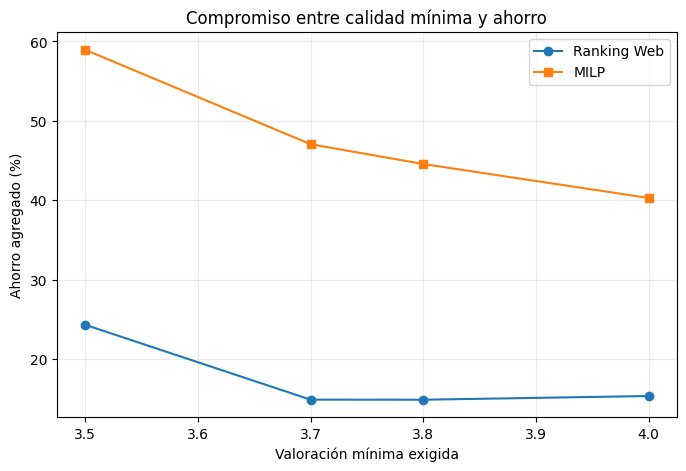

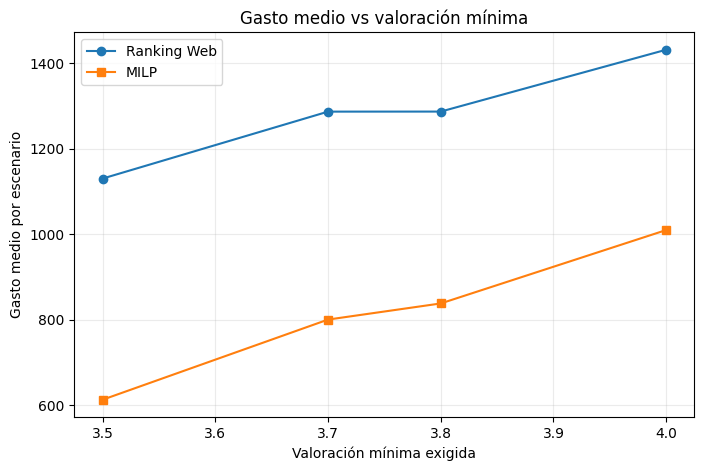

In [189]:
# ==========================================================
# Escenarios comparables
# ==========================================================
# Sólo se comparan escenarios donde:
# - MILP es factible
# - Ranking Web también obtuvo una solución válida
# ==========================================================

comparables = resultados_validacion[
    (resultados_validacion["Factible"])
    &
    (resultados_validacion["CosteRankingWeb"].notna())
].copy()

print(
    f"Escenarios MILP factibles: "
    f"{resultados_validacion[resultados_validacion['Factible']].shape[0]}"
)

print(
    f"Escenarios comparables Ranking-MILP: "
    f"{comparables.shape[0]}"
)

sensibilidad_global = (
    comparables
    .groupby("UmbralValoracion")
    .agg(
        CosteReferenciaTotal=("CosteReferenciaForecast", "sum"),
        CosteRankingWebTotal=("CosteRankingWeb", "sum"),
        CosteOptimizadoTotal=("CosteOptimizado", "sum"),
        Escenarios=("Factible", "size")
    )
    .reset_index()
)

# ==========================================================
# Ahorro vs referencia
# ==========================================================

sensibilidad_global["AhorroRankingVsReferencia"] = (
    sensibilidad_global["CosteReferenciaTotal"]
    - sensibilidad_global["CosteRankingWebTotal"]
)

sensibilidad_global["AhorroMILPVsReferencia"] = (
    sensibilidad_global["CosteReferenciaTotal"]
    - sensibilidad_global["CosteOptimizadoTotal"]
)

sensibilidad_global["AhorroPctRankingVsReferencia"] = (
    100
    * sensibilidad_global["AhorroRankingVsReferencia"]
    / sensibilidad_global["CosteReferenciaTotal"]
)

sensibilidad_global["AhorroPctMILPVsReferencia"] = (
    100
    * sensibilidad_global["AhorroMILPVsReferencia"]
    / sensibilidad_global["CosteReferenciaTotal"]
)

# ==========================================================
# Gasto vs escenarios posibles
# ==========================================================

sensibilidad_global["GastoRankingPorEscenario"] = (
    sensibilidad_global["CosteRankingWebTotal"]
    / sensibilidad_global["Escenarios"]
)

sensibilidad_global["GastoMILPPorEscenario"] = (
    sensibilidad_global["CosteOptimizadoTotal"]
    / sensibilidad_global["Escenarios"]
)

display(
    sensibilidad_global.round(3)
)

# ==========================================================
# Gráfico
# ==========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    sensibilidad_global["UmbralValoracion"],
    sensibilidad_global["AhorroPctRankingVsReferencia"],
    marker="o",
    label="Ranking Web"
)

plt.plot(
    sensibilidad_global["UmbralValoracion"],
    sensibilidad_global["AhorroPctMILPVsReferencia"],
    marker="s",
    label="MILP"
)

plt.xlabel("Valoración mínima exigida")
plt.ylabel("Ahorro agregado (%)")
plt.title("Compromiso entre calidad mínima y ahorro")
plt.grid(True, alpha=0.25)
plt.legend()

plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    sensibilidad_global["UmbralValoracion"],
    sensibilidad_global["GastoRankingPorEscenario"],
    marker="o",
    label="Ranking Web"
)

plt.plot(
    sensibilidad_global["UmbralValoracion"],
    sensibilidad_global["GastoMILPPorEscenario"],
    marker="s",
    label="MILP"
)

plt.xlabel("Valoración mínima exigida")
plt.ylabel("Gasto medio por escenario")
plt.title("Gasto medio vs valoración mínima")
plt.grid(True, alpha=0.25)
plt.legend()

plt.show()


## 14. Conclusiones

El sistema queda organizado en una cadena coherente:

**Forecast → MILP → Ranking Web → seguimiento de asignación**

El forecast define la demanda futura sobre la que se trabaja. El MILP determina una distribución objetivo entre proveedores, y el ranking web utiliza esa distribución como una señal de recomendación, sin convertirla en una restricción que elimine proveedores.

La elección de los pesos del ranking se fundamenta en un análisis de sensibilidad que compara ahorro, valoración media, capacidad y cuota MILP. La combinación recomendada es la que obtiene el mejor equilibrio entre los indicadores normalizados.

In [225]:
todos = resultados_validacion.copy()
factibles = todos[todos["Factible"]].copy()

print("CONCLUSIONES")
print("=" * 75)
print(f"Series objetivo del forecast: {len(series_objetivo):,}")
print(
    "Series con demanda prevista > 0 y demanda operativa >= 1: "
    f"{len(series_objetivo):,}"
)
print(
    f"Tratamientos objetivo: "
    f"{forecast_completo['CODIGO_TRATAMIENTO'].nunique():,}"
)
print(
    f"Municipios objetivo: "
    f"{forecast_completo['CODIGO_MUNICIPIO'].nunique():,}"
)
print(
    f"Demanda prevista total (4 semanas, 50 series): "
    f"{demanda_total_forecast:,.2f}"
)
print(
    "Capacidad: dato real CAPACIDAD_ANUAL, convertido a horizonte "
    "de 4 semanas (4/52)."
)
print(f"Umbrales analizados: {UMBRALES_VALORACION}")
print(
    f"Umbral utilizado como escenario principal: "
    f"{UMBRAL_SELECCIONADO:.1f}"
)

if not sensibilidad_pesos.empty:
    mejor = sensibilidad_pesos.iloc[0]

    print()
    print("PESOS RECOMENDADOS POR SENSIBILIDAD")
    print(
        f"Coste: {mejor['PesoCoste']:.0%} | "
        f"Valoración: {mejor['PesoValoracion']:.0%} | "
        f"Capacidad: {mejor['PesoCapacidad']:.0%} | "
        f"Cuota MILP: {mejor['PesoCuotaMILP']:.0%}"
    )
    print(
        f"Valoración media: {mejor['ValoracionMedia']:.3f} | "
        f"Escenarios factibles: "
        f"{int(mejor['EscenariosFactibles'])}/"
        f"{int(mejor['EscenariosTotales'])}"
    )
    print( f"AHORRO: {mejor['AhorroPct']:.2f}%  ")
seleccion = factibles[
    np.isclose(
        factibles["UmbralValoracion"],
        UMBRAL_SELECCIONADO
    )
].copy()

if seleccion.empty:
    print()
    print("No hay escenarios factibles para el umbral seleccionado.")
else:
    coste_ref = seleccion["CosteReferenciaForecast"].sum()
    coste_opt = seleccion["CosteOptimizado"].sum()

    print()
    print("MILP")
    print(f"Escenarios factibles(umbral 3.7): {len(seleccion):,}")
    print(
        f"Escenarios no factibles: "
        f"{len(resultados_validacion) // len(UMBRALES_VALORACION) - len(seleccion):,}"
    )
    print(
        f"Ahorro total ideal vs referencia: "
        f"{coste_ref - coste_opt:,.2f} $"
    )
    print(
        f"Ahorro porcentual ideal vs referencia: "
        f"{100*(coste_ref-coste_opt)/coste_ref:.2f}%"
    )

print()
print("INTERPRETACIÓN")
print(
    "- El forecast define la demanda futura sobre la que se realiza la asignación."
)
print(
    "- El MILP minimiza el coste total, "
    "respetando demanda, capacidad y umbral de valoración."
)
print(
    "- Las cuotas objetivo MILP orientan el ranking, pero no excluyen "
    "proveedores viables."
)

print(
    "- La capacidad se interpreta de forma relativa a la demanda prevista "
    "mediante CapacidadRelativa."
)
print(
    "- La selección de pesos se fundamenta en ahorro, valoración media "
    "y capacidad y cuota MILP."
)



CONCLUSIONES
Series objetivo del forecast: 45
Series con demanda prevista > 0 y demanda operativa >= 1: 45
Tratamientos objetivo: 40
Municipios objetivo: 5
Demanda prevista total (4 semanas, 50 series): 290.20
Capacidad: dato real CAPACIDAD_ANUAL, convertido a horizonte de 4 semanas (4/52).
Umbrales analizados: [3.5, 3.7, 3.8, 4.0]
Umbral utilizado como escenario principal: 3.7

PESOS RECOMENDADOS POR SENSIBILIDAD
Coste: 35% | Valoración: 45% | Capacidad: 10% | Cuota MILP: 10%
Valoración media: 4.082 | Escenarios factibles: 38/45
AHORRO: 14.91%  

MILP
Escenarios factibles(umbral 3.7): 43
Escenarios no factibles: 2
Ahorro total ideal vs referencia: 26,919.68 $
Ahorro porcentual ideal vs referencia: 44.41%

INTERPRETACIÓN
- El forecast define la demanda futura sobre la que se realiza la asignación.
- El MILP minimiza el coste total, respetando demanda, capacidad y umbral de valoración.
- Las cuotas objetivo MILP orientan el ranking, pero no excluyen proveedores viables.
- La capacidad s